In [1]:
import os
import json

In [2]:
def load_kaggle_creds(kaggle_cred_file):
    with open(kaggle_cred_file, "r") as f:
        credentials = json.load(f)
    for i,j in credentials.items():
        os.environ[f'KAGGLE_{i}'] = j 

In [3]:
def download_competition_data():
    downloaded_file = f'{competition}.zip'
    if not os.path.exists(downloaded_file):
        print('Downloading data files')
        api = KaggleApi()
        api.authenticate()
        api.competition_download_files(competition)
    if os.path.exists('data') and os.listdir('data'):
        print('Data files already found')
    else:
        print('Unzipping data files')
        with zipfile.ZipFile(downloaded_file, "r") as zip_ref:
            zip_ref.extractall('data')  # Extracts all files

In [4]:
def show_box_plot(data, categorical_cols, target_col):
    """Generates box plots for multiple categorical variables."""
    num_plots = len(categorical_cols)
    fig, axes = plt.subplots(num_plots, 1, figsize=(5, 5*num_plots), sharey=True)

    if num_plots == 1:
        axes = [axes]  # Ensure axes is iterable for a single plot

    for col, ax in zip(categorical_cols, axes):
        sns.boxplot(x=data[col], y=data[target_col], ax=ax, 
                    boxprops={'facecolor': 'lightgray', 'alpha': 0.6},  # Light fill color
                    medianprops={'color': 'red', 'linewidth': 2})  # Emphasize median

        ax.set_title(f"Boxplot of {target_col} vs {col}")
        ax.set_xlabel(col)
        ax.set_ylabel(target_col)
        ax.tick_params(axis='x', rotation=45)  # Rotate labels for readability

    plt.tight_layout()
    plt.show()

In [5]:
class DataSummary:
    def __init__(self,df):
        self.cat_cols = ['Brand', 'Material', 'Size','Laptop Compartment', 'Waterproof', 'Style', 'Color']
        self.int_cols =  ['Compartments']
        self.float_cols = ['Weight Capacity (kg)']
        self.df = df.copy()
        self.mode_dict = {}
        self.mean_dict = {}

        self.scaler = None
    def imputer(self):
        for col in self.cat_cols + self.int_cols:
            self.mode_dict[col] = self.df[col].mode()[0]
        for col in self.float_cols:
            self.mean_dict[col] = float(self.df[col].mean())
        return {**self.mode_dict, **self.mean_dict}        
    
    def allowed_values(self):
        values_seen = {}
        for col in self.cat_cols + self.int_cols:
            values_seen[col] = self.df[col].dropna().unique().tolist()
        return values_seen
    def fit(self):
        self.mode_dict = self.imputer()
        self.allowed_values = self.allowed_values()
        self.scaler
        return self
    
    def transform(self, df=None):
        df = df if df is not None else self.df
        for col in self.cat_cols + self.int_cols:
            df[col] = df[col].fillna(self.mode_dict[col])
            df.loc[~df[col].isin(self.allowed_values[col]), col] = self.mode_dict[col]

        for col in self.cat_cols:
            df[col] = df[col].astype('category') 
        for col in self.float_cols:
            df[col] = df[col].fillna(self.mean_dict[col])
        return df

In [6]:
kaggle_cred_file = r'E:\env\KAGGLE_KEY\kaggle.json'
load_kaggle_creds(kaggle_cred_file)

In [7]:
from kaggle.api_client import ApiClient
from kaggle.api.kaggle_api_extended import KaggleApi

In [8]:
competition = 'playground-series-s5e2'

In [9]:
import zipfile

In [10]:
download_competition_data()

Data files already found


In [11]:
os.listdir('data')

['sample_submission.csv', 'test.csv', 'train.csv', 'training_extra.csv']

In [15]:
train_file = 'data/train.csv'

In [16]:
import pandas as pd

In [17]:
train_df = pd.read_csv(train_file)

In [18]:
train_df =train_df.drop(columns = ['id'])

In [19]:
train_df.head()

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312


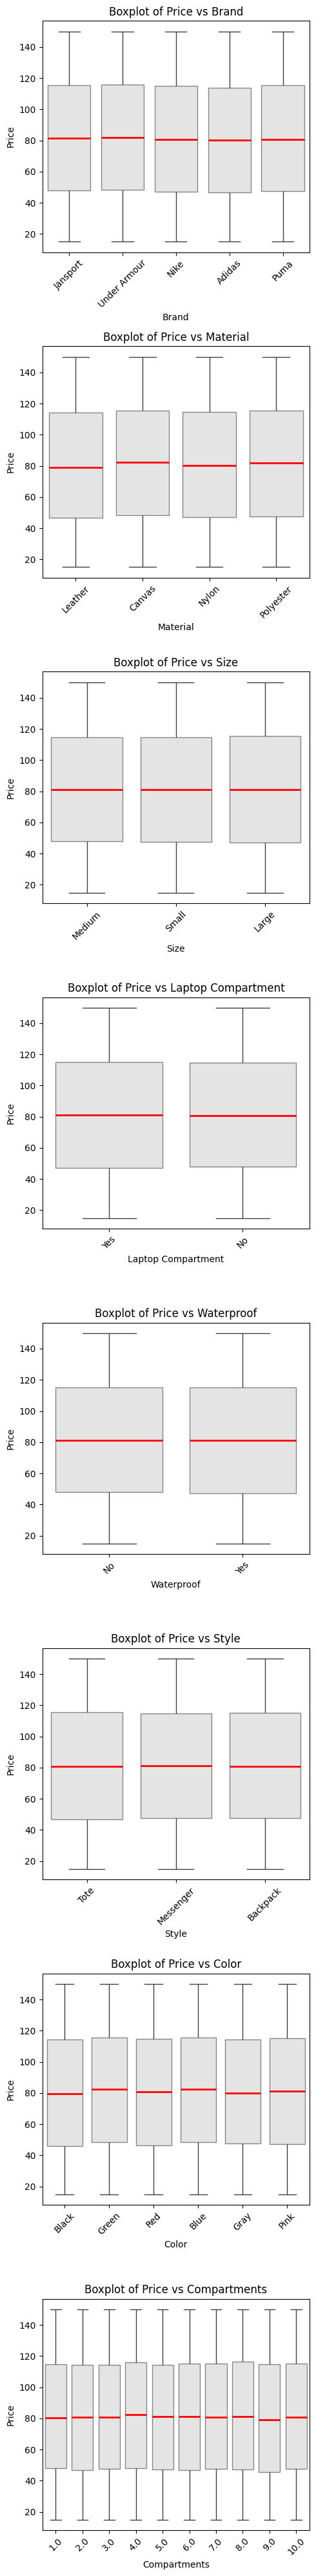

In [32]:
cat_cols = ['Brand', 'Material', 'Size','Laptop Compartment', 'Waterproof', 'Style', 'Color'] + ['Compartments'] # Replace with your categorical columns
target_col = "Price"
show_box_plot(train_df, cat_cols, target_col)

In [48]:
import numpy as np

In [57]:
from scipy.stats import f_oneway
from scipy.stats import kruskal

for col in cat_cols:    
    groups = [y[train_df[col] == cat] for cat in train_df[col].dropna().unique()]
    stat, p_value = f_oneway(*groups)    
    stat, p_value_kw = kruskal(*groups)

    grand_mean = np.mean(y)
    ss_total = np.sum((y - grand_mean) ** 2)
    ss_between = sum(len(y[train_df[col] == cat]) * (np.mean(y[train_df[col] == cat]) - grand_mean) ** 2 for cat in train_df[col].dropna().unique())
    eta_squared = ss_between / ss_total

    means = train_df.groupby(col)['Price'].mean()
    print(f"Col Name -> {col:<20} | {train_df[col].nunique()} | ANOVA p-value: {p_value:.4f}  | KW : {p_value_kw:.4f} | Eta sqrd : {eta_squared:.4f}")
    #print(means)


Col Name -> Brand                | 5 | ANOVA p-value: 0.0000  | KW : 0.0000 | Eta sqrd : 0.0001
Col Name -> Material             | 4 | ANOVA p-value: 0.0000  | KW : 0.0000 | Eta sqrd : 0.0003
Col Name -> Size                 | 3 | ANOVA p-value: 0.1891  | KW : 0.2343 | Eta sqrd : 0.0000
Col Name -> Laptop Compartment   | 2 | ANOVA p-value: 0.9952  | KW : 0.9233 | Eta sqrd : 0.0000
Col Name -> Waterproof           | 2 | ANOVA p-value: 0.2424  | KW : 0.2074 | Eta sqrd : 0.0000
Col Name -> Style                | 3 | ANOVA p-value: 0.9774  | KW : 0.9661 | Eta sqrd : 0.0000
Col Name -> Color                | 6 | ANOVA p-value: 0.0000  | KW : 0.0000 | Eta sqrd : 0.0003
Col Name -> Compartments         | 10 | ANOVA p-value: 0.0001  | KW : 0.0001 | Eta sqrd : 0.0001


In [88]:
summary  = DataSummary(train_df)

In [89]:
fitted_values = summary.fit()

In [90]:
train_df_transformed = summary.transform()

In [91]:
train_df_transformed.head()

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Jansport,Leather,Medium,7,Yes,No,Tote,Black,11.611723,112.15875
1,Jansport,Canvas,Small,10,Yes,Yes,Messenger,Green,27.078537,68.88056
2,Under Armour,Leather,Small,2,Yes,No,Messenger,Red,16.643760,39.17320
3,Nike,Nylon,Small,8,Yes,No,Messenger,Green,12.937220,80.60793
4,Adidas,Canvas,Medium,1,Yes,Yes,Messenger,Green,17.749338,86.02312


In [92]:
X = train_df_transformed.drop(columns = 'Price')
y = train_df_transformed['Price']

In [93]:
y.shape

(300000,)

In [94]:
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
model = xgb.XGBRegressor(
    objective="reg:squarederror",  # Standard objective for regression
    n_estimators=100,              # Number of trees
    learning_rate=0.1,             # Step size shrinkage
    max_depth=3,                   # Maximum depth of a tree
    random_state=42,
    enable_categorical = True
)


In [97]:
%%time

model.fit(X_train, y_train)

CPU times: total: 1.77 s
Wall time: 584 ms


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [98]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [99]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")

Mean Squared Error: 1514.3408
Mean Absolute Error: 33.6406


In [100]:
y_train.mean()

np.float64(81.44848108591667)

In [101]:
from sklearn.model_selection import KFold
import numpy as np

In [102]:
# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store RMSE scores for each fold
rmse_train, rmse_test = [], []
mae_train, mae_test = [], []

xgb_reg = model
# Perform manual cross-validation
for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx] 
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] 

    # Train the model
    xgb_reg.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    rmse_train.append(train_rmse)
    rmse_test.append(test_rmse)
    mae_train.append(train_mae)
    mae_test.append(test_mae)

    print(f"Fold {fold}: Train RMSE = {train_rmse:.4f}, Test RMSE = {test_rmse:.4f}")
    print(f"         Train MAE  = {train_mae:.4f}, Test MAE  = {test_mae:.4f}\n")

# Average scores across folds
print("Average Train RMSE:", np.mean(rmse_train))
print("Average Test RMSE:", np.mean(rmse_test))
print("Average Train MAE:", np.mean(mae_train))
print("Average Test MAE:", np.mean(mae_test))

Fold 1: Train RMSE = 38.9990, Test RMSE = 38.9156
         Train MAE  = 33.7592, Test MAE  = 33.6397

Fold 2: Train RMSE = 38.9672, Test RMSE = 39.0459
         Train MAE  = 33.7230, Test MAE  = 33.7917

Fold 3: Train RMSE = 38.9721, Test RMSE = 39.0188
         Train MAE  = 33.7293, Test MAE  = 33.7525

Fold 4: Train RMSE = 38.9581, Test RMSE = 39.0768
         Train MAE  = 33.6986, Test MAE  = 33.8834

Fold 5: Train RMSE = 38.9740, Test RMSE = 39.0099
         Train MAE  = 33.7313, Test MAE  = 33.7460

Average Train RMSE: 38.97407808080911
Average Test RMSE: 39.01341088995731
Average Train MAE: 33.72826078099855
Average Test MAE: 33.76265351822343


In [114]:
test_file = r'E:\KAGGLE\s05e02_bagpack prediction\data\test.csv'
test_df = pd.read_csv(test_file)
ids = test_df['id'].values
test_df = test_df.drop(columns=['id'])

In [115]:
test_df_processed = summary.transform(test_df)

In [116]:
y_pred = model.predict(test_df_processed)

In [120]:
submission_df = pd.DataFrame({'id':ids, 'Price': y_pred})


In [124]:
sumission_file = "my_submission_20250224145600.csv"

In [125]:
submission_df.to_csv(sumission_file, index=False) 

In [126]:
competition_name = competition
submission_file = sumission_file
message = f"My first submission for {competition_name}"

In [127]:
api = KaggleApi()
api.authenticate()

In [129]:
import subprocess

In [130]:
command = f"kaggle competitions submit -c {competition_name} -f {submission_file} -m \"{message}\""
subprocess.run(command, shell=True)

CompletedProcess(args='kaggle competitions submit -c playground-series-s5e2 -f my_submission_20250224145600.csv -m "My first submission for playground-series-s5e2"', returncode=0)

In [12]:
competition

'playground-series-s5e2'

In [14]:
import kaggle

In [15]:
kaggle.api.competition_leaderboard(competition, path=".")

AttributeError: 'KaggleApi' object has no attribute 'competition_leaderboard'

In [16]:
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()

In [17]:
api.authenticate()

In [18]:
dir(api)

['CONFIG_NAME_COMPETITION',
 'CONFIG_NAME_KEY',
 'CONFIG_NAME_PATH',
 'CONFIG_NAME_PROXY',
 'CONFIG_NAME_SSL_CA_CERT',
 'CONFIG_NAME_USER',
 'DATASET_METADATA_FILE',
 'HEADER_API_VERSION',
 'KERNEL_METADATA_FILE',
 'MAX_NUM_INBOX_FILES_TO_UPLOAD',
 'MAX_UPLOAD_RESUME_ATTEMPTS',
 'MODEL_INSTANCE_METADATA_FILE',
 'MODEL_METADATA_FILE',
 'OLD_DATASET_METADATA_FILE',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__version__',
 '__weakref__',
 '_calculate_backoff_delay',
 '_get_bytes_already_uploaded',
 '_is_help_or_version_command',
 '_is_retriable',
 '_is_upload_successful',
 '_load_config',
 '_print_dataset_url_and_license',
 '_read_config_file',
 '_resume_upload',
 

In [54]:
for i in dir(api):
    if 'rank' in i:
        print(i)

In [46]:
for i in dir(api):
    if 'submission' in i:
        print(i)

competition_submissions
competition_submissions_cli
competitions_submissions_list
competitions_submissions_list_with_http_info
competitions_submissions_submit
competitions_submissions_submit_with_http_info
competitions_submissions_upload
competitions_submissions_upload_with_http_info
competitions_submissions_url
competitions_submissions_url_with_http_info


In [49]:
api.competitions_submissions_list(competition)

[{'totalBytesNullable': 3430420,
  'descriptionNullable': 'My first submission for playground-series-s5e2',
  'errorDescriptionNullable': '',
  'fileNameNullable': 'my_submission_20250224145600.csv',
  'publicScoreNullable': '39.14399',
  'privateScoreNullable': '38.93684',
  'submittedByNullable': 'yash1158',
  'submittedByRefNullable': 'yash1158',
  'teamNameNullable': 'Yash',
  'urlNullable': '/submissions/43073029/43073029.raw',
  'ref': 43073029,
  'totalBytes': 3430420,
  'hasTotalBytes': True,
  'date': '2025-02-24T09:29:26.527Z',
  'description': 'My first submission for playground-series-s5e2',
  'hasDescription': True,
  'errorDescription': '',
  'hasErrorDescription': True,
  'fileName': 'my_submission_20250224145600.csv',
  'hasFileName': True,
  'publicScore': '39.14399',
  'hasPublicScore': True,
  'privateScore': '38.93684',
  'hasPrivateScore': True,
  'status': 'complete',
  'submittedBy': 'yash1158',
  'hasSubmittedBy': True,
  'submittedByRef': 'yash1158',
  'hasSubm

In [50]:
my_submissions = api.competitions_submissions_list(competition)

In [51]:
if my_submissions is not None:
    my_submissions_df = pd.DataFrame(my_submissions)
else:
    my_submissions_df = None

In [53]:
my_submissions_df.T

,0
totalBytesNullable,3430420
descriptionNullable,My first submission for playground-series-s5e2
errorDescriptionNullable,
fileNameNullable,my_submission_20250224145600.csv
publicScoreNullable,39.14399
privateScoreNullable,38.93684
submittedByNullable,yash1158
submittedByRefNullable,yash1158
teamNameNullable,Yash
urlNullable,/submissions/43073029/43073029.raw


In [38]:
help(api.competition_view_leaderboard_with_http_info)

Help on method competition_view_leaderboard_with_http_info in module kaggle.api.kaggle_api:

competition_view_leaderboard_with_http_info(id, **kwargs) method of kaggle.api.kaggle_api_extended.KaggleApi instance
    VIew competition leaderboard  # noqa: E501
    
    This method makes a synchronous HTTP request by default. To make an
    asynchronous HTTP request, please pass async_req=True
    >>> thread = api.competition_view_leaderboard_with_http_info(id, async_req=True)
    >>> result = thread.get()
    
    :param async_req bool
    :param str id: Competition name (required)
    :return: Result
             If the method is called asynchronously,
             returns the request thread.



In [34]:
import pandas as pd

In [43]:
x = api.competition_leaderboard_view(competition)

In [44]:
leaderboard = pd.DataFrame([i.__dict__ for i in x])

In [45]:
leaderboard.head(10)

,teamNameNullable,scoreNullable,teamId,teamName,hasTeamName,submissionDate,score,hasScore
0,Chris Deotte,38.61628,13283643,Chris Deotte,True,2025-02-28 23:32:01,38.61628,True
1,Ravi Ramakrishnan,38.62947,13281539,Ravi Ramakrishnan,True,2025-02-28 21:31:14,38.62947,True
2,automatylicza_knai,38.63283,13282771,automatylicza_knai,True,2025-02-28 23:49:31,38.63283,True
3,Pascal Terpstra,38.63446,13281586,Pascal Terpstra,True,2025-02-28 23:52:09,38.63446,True
4,Optimistix,38.63455,13281580,Optimistix,True,2025-02-28 23:55:47,38.63455,True
5,Masaya Kawamata,38.63456,13281636,Masaya Kawamata,True,2025-02-28 23:55:41,38.63456,True
6,Mikhail Naumov,38.63456,13283098,Mikhail Naumov,True,2025-02-28 22:58:54,38.63456,True
7,Nick,38.63568,13281696,Nick,True,2025-02-28 23:58:18,38.63568,True
8,LETS GO,38.63748,13314187,LETS GO,True,2025-02-27 21:48:48,38.63748,True
9,hrncixi,38.63755,13405415,hrncixi,True,2025-02-28 12:58:41,38.63755,True


In [30]:
i.__dict__

{'teamNameNullable': 'Saumil Patel',
 'scoreNullable': '150367.10366',
 'teamId': 13282217,
 'teamName': 'Saumil Patel',
 'hasTeamName': True,
 'submissionDate': datetime.datetime(2025, 2, 1, 6, 55, 33),
 'score': '150367.10366',
 'hasScore': True}